# Does VAR Lead to More Red Cards in one of the top 3 leagues in European Football?
### Difference-in-Differences Analysis - looking at the Premier League, Bundesliga, Ligue 1 (2014–2025)


Important to note: the three leagues selected were done so based on my interest and not due to any statistical reason behind the change.

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

#  Plot style
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})
PALETTE = {"Bundesliga": "#FF4958", "Ligue 1": "#5CFF77", "Premier League": "#59D0FF"}

Imports OK


## 2. Data Loading & Cleaning

In [2]:
# Load 
df = pd.read_csv(r"D:\2026\CEU\DA4\Final term paper\Sports\MasterData_14_to_25.csv")

# Drop empty columns
df = df.drop(columns=["Unnamed: 16", "Weight ", "Yellow", "1"], errors="ignore")

# Parsing the dates
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

df = df.dropna(subset=["Date"])

# Dropping the rows with missing match stats (there are only two of them)
df = df.dropna(subset=["HR", "AR", "HF", "AF", "HY", "AY"])

print(f"Matches loaded : {len(df):,}")
print(f"Leagues        : {sorted(df['Div'].unique())}")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")


Matches loaded : 11,475
Leagues        : ['Bundesliga', 'Ligue 1', 'Premier League']
Date range     : 2014-08-08 → 2025-05-25


## 3. Feature Engineering

In [3]:
# Defining the Football season as Aug–Jul
df["season_start"] = df["Date"].apply(
    lambda d: d.year if d.month >= 8 else d.year - 1
)
df["season"] = df["season_start"].apply(lambda y: f"{y}/{str(y+1)[-2:]}")

# Dropping rows where the date couldn't be parsed (NaN season_start)
n_before = len(df)
df = df.dropna(subset=["season_start"])
print(f"Dropped {n_before - len(df)} rows with unparseable dates. Remaining: {len(df):,}")

# Looking at total red cards, fouls, yellows per match
df["TR"] = df["HR"] + df["AR"]   # outcome Y
df["TF"] = df["HF"] + df["AF"]   # control Z — fouls
df["TY"] = df["HY"] + df["AY"]   # control Z — yellows

# Defining the VAR adoption season by league (~Aug of the adoption year)
VAR_ADOPTION = {
    "Bundesliga":     2017,   
    "Ligue 1":        2018,   
    "Premier League": 2019,
}
df["var_season"] = df["Div"].map(VAR_ADOPTION)
df["VAR"]        = (df["season_start"] >= df["var_season"]).astype(int)
df["rel_time"]   = df["season_start"] - df["var_season"]
df["home_win"]   = (df["FTR"] == "H").astype(int)

# Team fixed effects: unique identifier per team. Since 1 match = 2 teams, built HT and AT dummies separately.
# Teams are nested within leagues so league FEs are absorbed.
all_teams = sorted(set(df["HomeTeam"]) | set(df["AwayTeam"]))
print(f"Unique teams across all leagues: {len(all_teams)}")
print(f"VAR=0 matches: {(df['VAR']==0).sum():,}   VAR=1 matches: {df['VAR'].sum():,}")
print()
print(df[["Div", "season", "VAR", "rel_time", "TR", "TF", "TY"]].head(6))


Dropped 0 rows with unparseable dates. Remaining: 11,475
Unique teams across all leagues: 98
VAR=0 matches: 4,337   VAR=1 matches: 7,138

              Div   season  VAR  rel_time   TR    TF   TY
0  Premier League  2014/15    0        -5  1.0  32.0  4.0
1  Premier League  2014/15    0        -5  0.0  26.0  2.0
2  Premier League  2014/15    0        -5  0.0  34.0  6.0
3  Premier League  2014/15    0        -5  0.0  20.0  3.0
4  Premier League  2014/15    0        -5  0.0  23.0  3.0
5  Premier League  2014/15    0        -5  0.0  27.0  4.0


## 4. Summary Statistics

In [4]:
# Overall stats table
overall = df[["TR","TF","TY","VAR"]].describe().T
overall.columns = ["N","Mean","Std","Min","25%","50%","75%","Max"]
overall.index = ["Red cards / match","Fouls / match","Yellows / match","VAR (0/1)"]
print("=== Overall Summary Statistics ===")
print(overall.round(3).to_string())

# Pre vs post VAR outlook
print()
print("=== Pre- vs Post-VAR (pooled) ===")
pv = df.groupby("VAR")[["TR","TF","TY"]].mean().round(3)
pv.index = ["Pre-VAR","Post-VAR"]
pv.columns = ["Red cards / match","Fouls / match","Yellows / match"]
print(pv.to_string())

# League-wise outlook
print()
print("=== By League ===")
lg = df.groupby(["Div","VAR"])[["TR","TF","TY"]].agg(["mean","count"]).round(3)
print(lg.to_string())


=== Overall Summary Statistics ===
                         N    Mean    Std  Min   25%   50%   75%   Max
Red cards / match  11475.0   0.176  0.435  0.0   0.0   0.0   0.0   5.0
Fouls / match      11475.0  23.972  6.147  5.0  20.0  24.0  28.0  54.0
Yellows / match    11475.0   3.620  1.967  0.0   2.0   3.0   5.0  14.0
VAR (0/1)          11475.0   0.622  0.485  0.0   0.0   1.0   1.0   1.0

=== Pre- vs Post-VAR (pooled) ===
          Red cards / match  Fouls / match  Yellows / match
Pre-VAR               0.181         24.925            3.487
Post-VAR              0.172         23.392            3.700

=== By League ===
                       TR            TF           TY      
                     mean count    mean count   mean count
Div            VAR                                        
Bundesliga     0    0.161   918  29.400   918  3.718   918
               1    0.143  2447  23.553  2447  3.765  2447
Ligue 1        0    0.251  1519  26.357  1519  3.562  1519
               1    0.

## 5. Red Cards Over Time

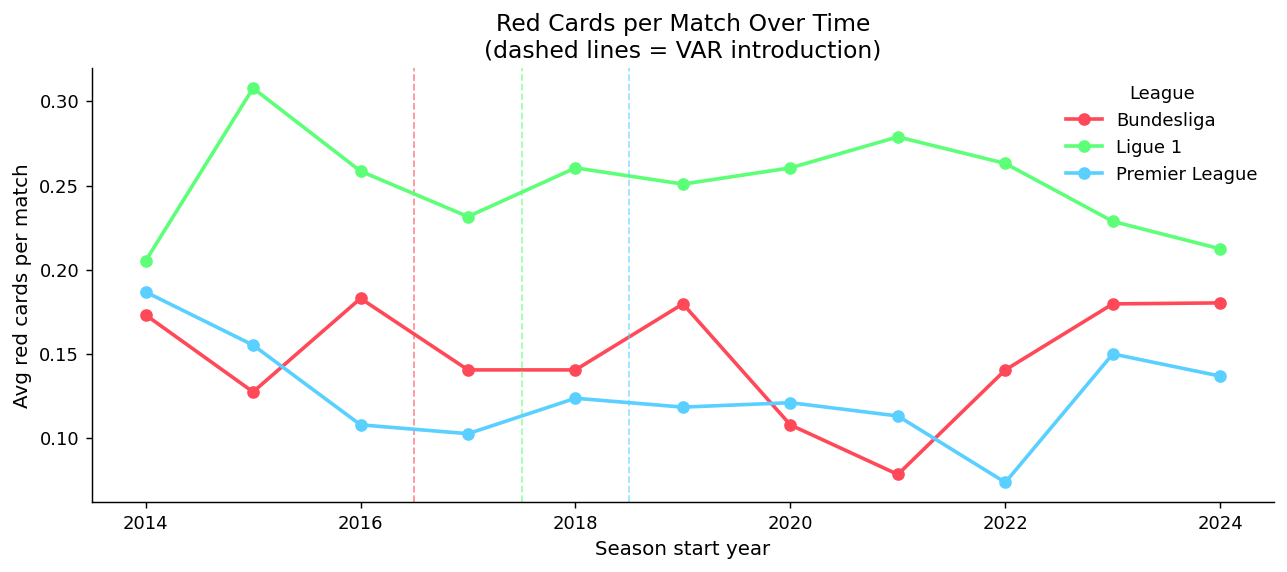

Saved: fig_redcards_over_time.png


In [5]:
# Aggregating it to league × season level
agg = (df.groupby(["Div", "season", "season_start", "var_season"])
         .agg(avg_red=("TR","mean"), n_matches=("TR","count"))
         .reset_index())
agg["VAR"] = (agg["season_start"] >= agg["var_season"]).astype(int)

fig, ax = plt.subplots(figsize=(10, 4.5))

for league, grp in agg.groupby("Div"):
    grp = grp.sort_values("season_start")
    ax.plot(grp["season_start"], grp["avg_red"],
            marker="o", label=league, color=PALETTE[league], linewidth=2)
# Vertical line = start of VAR adoption
    v = VAR_ADOPTION[league]
    ax.axvline(v - 0.5, color=PALETTE[league], linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("Season start year")
ax.set_ylabel("Avg red cards per match")
ax.set_title("Red Cards per Match Over Time\n(dashed lines = VAR introduction)")
ax.legend(title="League", frameon=False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig("fig_redcards_over_time.png", bbox_inches="tight")
plt.show()
print("Saved: fig_redcards_over_time.png")


## 6. DiD Event Study Plot
The event study replaces the single VAR dummy with a set of time dummies 
(seasons relative to each league's adoption year). The omitted category is the period of **t = −1** 
(the last pre-VAR season). Flat pre-trends support the parallel trend assumption (PTA).


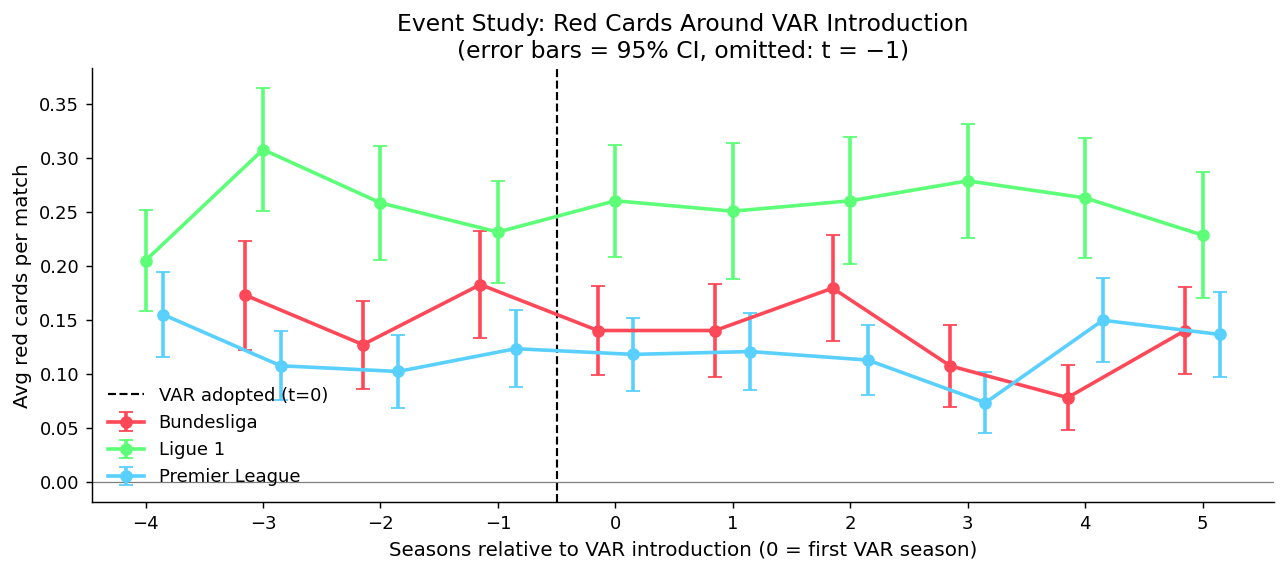

Saved: fig_event_study.png


In [6]:
# Aggregate to league × rel_time
event = (df.groupby(["Div", "rel_time"])
           .agg(avg_red=("TR","mean"), se=("TR", lambda x: x.std()/np.sqrt(len(x))))
           .reset_index())

# Keeping window from −4 to +5
event = event[event["rel_time"].between(-4, 5)]

fig, ax = plt.subplots(figsize=(10, 4.5))

for league, grp in event.groupby("Div"):
    grp = grp.sort_values("rel_time")
    ax.errorbar(grp["rel_time"] + {"Bundesliga":-0.15,"Ligue 1":0,"Premier League":0.15}[league],
                grp["avg_red"],
                yerr=1.96 * grp["se"],
                fmt="o-", label=league, color=PALETTE[league],
                linewidth=2, capsize=4, markersize=6)

ax.axvline(-0.5, color="black", linestyle="--", linewidth=1.2, label="VAR adopted (t=0)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_xlabel("Seasons relative to VAR introduction (0 = first VAR season)")
ax.set_ylabel("Avg red cards per match")
ax.set_title("Event Study: Red Cards Around VAR Introduction\n(error bars = 95% CI, omitted: t = −1)")
ax.legend(frameon=False)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("fig_event_study.png", bbox_inches="tight")
plt.show()
print("Saved: fig_event_study.png")


## 7. Main Regression through the Two-Way Fixed Effects DiD

Using the **OLS with home-team FE + away-team FE + season FE**, with **cluster-robust standard errors clustered at the league level**.

Team fixed effects replace league fixed effects: since teams are within leagues, team FEs take any league-level differences while also controlling for the difference in the team-specific playing style and referee familiarity.

$$\text{RedCards}_{mt} = \beta_0 + \beta_1 \cdot \text{VAR}_{lt} + \beta_2 \cdot \text{TF}_{mt} + \beta_3 \cdot \text{TY}_{mt} + \alpha^H_{h(m)} + \alpha^A_{a(m)} + \gamma_t + \varepsilon_{mt}$$

where $h(m)$ and $a(m)$ are the home and away teams in match $m$, $\alpha^H$ and $\alpha^A$ are home/away team FEs, and $\gamma_t$ is a season FE.


In [ ]:
# Having OLS helpers

def drop_collinear(X):
    # Drop columns with zero variance first
    var = X.var(axis=0)
    keep = np.where(var > 1e-12)[0]
    X = X[:, keep]
    # QR-based rank check to catch remaining linear dependencies
    Q, R = np.linalg.qr(X)
    rank = np.sum(np.abs(np.diag(R)) > 1e-10)
    if rank < X.shape[1]:
        # Keep only the first `rank` independent columns (pivoted QR)
        _, _, piv = np.linalg.svd(X, full_matrices=False)
        # Use SVD-based approach: drop columns below numerical rank
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        rank_svd = np.sum(s > 1e-10)
        # Rebuild X from top singular components
        X = U[:, :rank_svd] @ np.diag(s[:rank_svd]) @ Vt[:rank_svd, :]
    return X

def safe_inv(M):
    return np.linalg.pinv(M)

def ols_clustered(y, X, cluster_ids):
 
    n, k = X.shape
    XtX_inv = safe_inv(X.T @ X)
    coef    = XtX_inv @ X.T @ y
    resid   = y - X @ coef

    clusters = np.unique(cluster_ids)
    G        = len(clusters)
    meat     = np.zeros((k, k))
    for g in clusters:
        mask = cluster_ids == g
        Xg = X[mask]; eg = resid[mask]
        meat += Xg.T @ np.outer(eg, eg) @ Xg
    correction = (G / (G - 1)) * (n / (n - k))
    V   = correction * XtX_inv @ meat @ XtX_inv
    se  = np.sqrt(np.abs(np.diag(V)))          # abs guards tiny negatives from pinv
    tstat = coef / np.where(se > 0, se, np.inf)
    pval  = 2 * (1 - stats.t.cdf(np.abs(tstat), df=G - 1))
    return coef, se, tstat, pval, resid

def ols_hc1(y, X):

    n, k = X.shape
    XtX_inv = safe_inv(X.T @ X)
    coef    = XtX_inv @ X.T @ y
    resid   = y - X @ coef
    meat    = X.T @ np.diag(resid**2) @ X
    V       = (n / (n - k)) * XtX_inv @ meat @ XtX_inv
    se      = np.sqrt(np.abs(np.diag(V)))
    tstat   = coef / np.where(se > 0, se, np.inf)
    pval    = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    return coef, se, tstat, pval

def print_table(names, coef, se, tstat, pval, title="Regression Results"):
    stars = lambda p: "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.1 else ""))
    print(f"\n{'='*62}")
    print(f"  {title}")
    print(f"{'='*62}")
    print(f"  {'Variable':<28} {'Coef':>8} {'SE':>8} {'t':>7} {'p':>7}  ")
    print(f"  {'-'*58}")
    for n, c, s, t, p in zip(names, coef, se, tstat, pval):
        print(f"  {n:<28} {c:>8.4f} {s:>8.4f} {t:>7.2f} {p:>7.4f} {stars(p)}")
    print(f"{'='*62}")
    print("  Signif.: *** p<0.01  ** p<0.05  * p<0.1")
    print(f"{'='*62}")



Helpers defined.


In [8]:
# Build design matrix with team FEs
# Home-team dummies (drop first team alphabetically to act as teh baseline)
home_dummies = pd.get_dummies(df["HomeTeam"], prefix="HT", drop_first=True).astype(float)
# Away-team dummies (drop first team alphabetically to act as the baseline)
away_dummies = pd.get_dummies(df["AwayTeam"], prefix="AT", drop_first=True).astype(float)
# Season dummies
season_dummies = pd.get_dummies(df["season"], drop_first=True).astype(float)

y = df["TR"].values.astype(float)
# Team-level clustering is preferred over league (G=3) for valid inference.
cluster_ids = df["HomeTeam"].values  

print(f"Home team dummies : {home_dummies.shape[1]}")
print(f"Away team dummies : {away_dummies.shape[1]}")
print(f"Season dummies    : {season_dummies.shape[1]}")
print(f"Total observations: {len(y):,}")

# Model 1: VAR only + Team FEs + Season FE
X1 = np.column_stack([
    np.ones(len(df)),
    df["VAR"].values,
    home_dummies.values,
    away_dummies.values,
    season_dummies.values,
])
names1 = (["Intercept", "VAR (=1 after adoption)"]
          + list(home_dummies.columns)
          + list(away_dummies.columns)
          + list(season_dummies.columns))

c1, se1, t1, p1, _ = ols_clustered(y, X1, cluster_ids)
print_table(names1[:2], c1[:2], se1[:2], t1[:2], p1[:2],
            title="Model 1 — VAR + Home/Away Team FEs + Season FE")
print(f"  (Team and season FEs omitted from display)")
G = len(np.unique(cluster_ids))
print(f"  N = {len(y):,}   Teams (clusters) = {G}   Seasons = {df['season'].nunique()}")


Home team dummies : 97
Away team dummies : 97
Season dummies    : 10
Total observations: 11,475

  Model 1 — VAR + Home/Away Team FEs + Season FE
  Variable                         Coef       SE       t       p  
  ----------------------------------------------------------
  Intercept                      0.7569   0.2052    3.69  0.0004 ***
  VAR (=1 after adoption)        0.0084   0.0248    0.34  0.7354 
  Signif.: *** p<0.01  ** p<0.05  * p<0.1
  (Team and season FEs omitted from display)
  N = 11,475   Teams (clusters) = 98   Seasons = 11


In [9]:
# Model 2: VAR + fouls + yellows + Team FEs + Season FE
X2 = np.column_stack([
    np.ones(len(df)),
    df["VAR"].values,
    df["TF"].values,
    df["TY"].values,
    home_dummies.values,
    away_dummies.values,
    season_dummies.values,
])
names2 = (["Intercept", "VAR (=1 after adoption)", "Total fouls", "Total yellows"]
          + list(home_dummies.columns)
          + list(away_dummies.columns)
          + list(season_dummies.columns))

c2, se2, t2, p2, resid2 = ols_clustered(y, X2, cluster_ids)
print_table(names2[:4], c2[:4], se2[:4], t2[:4], p2[:4],
            title="Model 2 — VAR + Fouls + Yellows + Team FEs + Season FE")
print(f"  N = {len(y):,}")

ss_res = np.sum(resid2**2)
ss_tot = np.sum((y - y.mean())**2)
print(f"  R² = {1 - ss_res/ss_tot:.4f}")



  Model 2 — VAR + Fouls + Yellows + Team FEs + Season FE
  Variable                         Coef       SE       t       p  
  ----------------------------------------------------------
  Intercept                      0.6318   0.2026    3.12  0.0024 ***
  VAR (=1 after adoption)        0.0144   0.0237    0.61  0.5431 
  Total fouls                    0.0000   0.0009    0.03  0.9753 
  Total yellows                  0.0289   0.0038    7.62  0.0000 ***
  Signif.: *** p<0.01  ** p<0.05  * p<0.1
  N = 11,475
  R² = 0.0531


## 8. Robustness Checks

### 8.i. Smaller window (+/- 3 seasons around VAR adoption)
Restricts data to seasons close to each league's adoption to reduce confounders from long time trends.


In [10]:
# ── Narrow window (±3 seasons around VAR adoption) ───────────────────────────
df_win = df[df["rel_time"].between(-3, 3)].copy()
print(f"Window sample: {len(df_win):,} matches  ({df_win['season'].nunique()} unique seasons)")

hd_w = pd.get_dummies(df_win["HomeTeam"], prefix="HT", drop_first=True).astype(float)
ad_w = pd.get_dummies(df_win["AwayTeam"], prefix="AT", drop_first=True).astype(float)
sd_w = pd.get_dummies(df_win["season"],   drop_first=True).astype(float)
y_w  = df_win["TR"].values.astype(float)
cl_w = df_win["HomeTeam"].values  # team-level clustering

X_win = np.column_stack([
    np.ones(len(df_win)),
    df_win["VAR"].values,
    df_win["TF"].values,
    df_win["TY"].values,
    hd_w.values, ad_w.values, sd_w.values,
])
n_win = (["Intercept", "VAR", "Total fouls", "Total yellows"]
         + list(hd_w.columns) + list(ad_w.columns) + list(sd_w.columns))

cw, sew, tw, pw, _ = ols_clustered(y_w, X_win, cl_w)
print_table(n_win[:4], cw[:4], sew[:4], tw[:4], pw[:4],
            title="Robustness: ±3-Season Window — Team FEs + Season FE")


Window sample: 7,360 matches  (9 unique seasons)

  Robustness: ±3-Season Window — Team FEs + Season FE
  Variable                         Coef       SE       t       p  
  ----------------------------------------------------------
  Intercept                      0.0247   0.0908    0.27  0.7865 
  VAR                            0.0136   0.0243    0.56  0.5785 
  Total fouls                    0.0015   0.0009    1.65  0.1027 
  Total yellows                  0.0255   0.0046    5.54  0.0000 ***
  Signif.: *** p<0.01  ** p<0.05  * p<0.1


### 8.ii. Poisson regression

In [11]:
# Poisson via MLE
def poisson_nll(beta, X, y):
    mu = np.exp(np.clip(X @ beta, -30, 30))
    return -np.sum(y * np.log(mu + 1e-12) - mu)

def poisson_grad(beta, X, y):
    mu = np.exp(np.clip(X @ beta, -30, 30))
    return X.T @ (mu - y)

res_pois = minimize(poisson_nll, c2, args=(X2, y),
                    jac=poisson_grad, method="L-BFGS-B",
                    options={"maxiter": 1000})
b_pois = res_pois.x

# Poisson robust SE (sandwich)
mu_hat = np.exp(np.clip(X2 @ b_pois, -30, 30))
fisher = X2.T @ np.diag(mu_hat) @ X2
try:
    V_pois = np.linalg.pinv(fisher)
    se_pois = np.sqrt(np.abs(np.diag(V_pois)))
except Exception:
    se_pois = np.full(len(b_pois), np.nan)

t_pois = b_pois / np.where(se_pois > 0, se_pois, np.inf)
p_pois = 2 * (1 - stats.norm.cdf(np.abs(t_pois)))

print_table(names2[:4], b_pois[:4], se_pois[:4], t_pois[:4], p_pois[:4],
            title="Robustness: Poisson MLE (Team FEs + Season FE)")
print(f"  IRR for VAR: exp({b_pois[1]:.4f}) = {np.exp(b_pois[1]):.4f}")
print(f"  Convergence: {res_pois.message}")



  Robustness: Poisson MLE (Team FEs + Season FE)
  Variable                         Coef       SE       t       p  
  ----------------------------------------------------------
  Intercept                     -1.2289   0.6573   -1.87  0.0615 *
  VAR (=1 after adoption)        0.0869   0.1393    0.62  0.5327 
  Total fouls                    0.0006   0.0044    0.15  0.8840 
  Total yellows                  0.1576   0.0120   13.17  0.0000 ***
  Signif.: *** p<0.01  ** p<0.05  * p<0.1
  IRR for VAR: exp(0.0869) = 1.0908
  Convergence: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


## 9. Heterogeneity Analysis

Does VAR's effect differ **across leagues**? I ran separate per-league regressions.

With 3 extra years of pre-VAR Bundesliga data (2014–2016), all three leagues are now estimable. Within each league I used a **linear time trend** instead of season dummies to avoid perfect collinearity with the VAR step function, plus team dummies for the home and away sides.


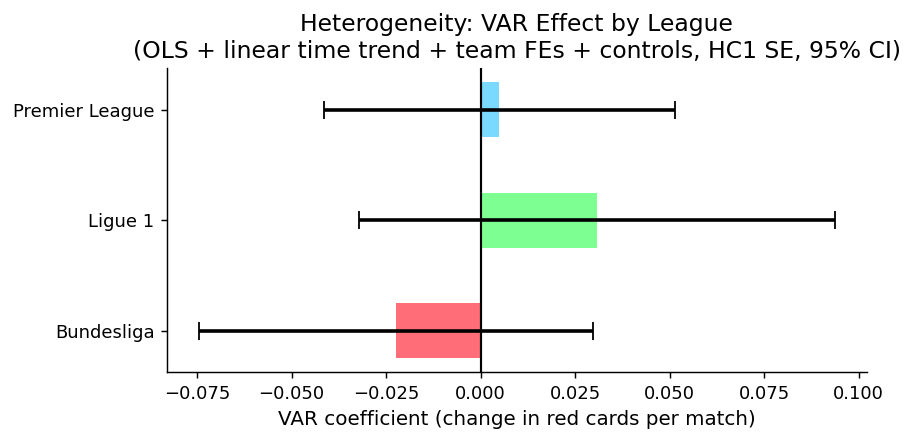

Bundesliga            β=-0.0224  SE=0.0266  95% CI [-0.0745, +0.0297]  N=3,365
Ligue 1               β=+0.0308  SE=0.0321  95% CI [-0.0321, +0.0937]  N=3,930
Premier League        β=+0.0049  SE=0.0237  95% CI [-0.0415, +0.0514]  N=4,180


In [12]:
# Per-league VAR effect with all three leagues estimable
results_het = {}
for league in sorted(df["Div"].unique()):
    sub = df[df["Div"] == league].copy()
    sub["time_trend"] = sub["season_start"] - sub["season_start"].min()

    hd = pd.get_dummies(sub["HomeTeam"], prefix="HT", drop_first=True).astype(float)
    ad = pd.get_dummies(sub["AwayTeam"], prefix="AT", drop_first=True).astype(float)

    y_sub = sub["TR"].values.astype(float)
    X_sub = np.column_stack([
        np.ones(len(sub)),
        sub["VAR"].values,
        sub["TF"].values,
        sub["TY"].values,
        sub["time_trend"].values,
        hd.values,
        ad.values,
    ])
    coef_s, se_s, _, _ = ols_hc1(y_sub, X_sub)
    results_het[league] = {
        "coef":  coef_s[1],
        "se":    se_s[1],
        "ci_lo": coef_s[1] - 1.96 * se_s[1],
        "ci_hi": coef_s[1] + 1.96 * se_s[1],
        "n":     len(sub),
    }

# Coefficient plot
fig, ax = plt.subplots(figsize=(7, 3.5))
leagues_plot = sorted(results_het.keys())
coefs  = [results_het[l]["coef"]  for l in leagues_plot]
ci_lo  = [results_het[l]["ci_lo"] for l in leagues_plot]
ci_hi  = [results_het[l]["ci_hi"] for l in leagues_plot]

y_pos = np.arange(len(leagues_plot))
ax.barh(y_pos, coefs, color=[PALETTE[l] for l in leagues_plot], alpha=0.8, height=0.5)
ax.errorbar(coefs, y_pos,
            xerr=[np.array(coefs) - np.array(ci_lo),
                  np.array(ci_hi) - np.array(coefs)],
            fmt="none", color="black", capsize=5, linewidth=2)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(leagues_plot)
ax.set_xlabel("VAR coefficient (change in red cards per match)")
ax.set_title("Heterogeneity: VAR Effect by League\n"
             "(OLS + linear time trend + team FEs + controls, HC1 SE, 95% CI)")
plt.tight_layout()
plt.savefig("fig_heterogeneity.png", bbox_inches="tight")
plt.show()

for l in leagues_plot:
    r = results_het[l]
    print(f"{l:20s}  β={r['coef']:+.4f}  SE={r['se']:.4f}  "
          f"95% CI [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]  N={r['n']:,}")


## 10. Results Summary Table

Consolidating all models in one comparison table.


In [13]:
# VAR coefficient across all models
summary_rows = [
    ("(1) TWFE — VAR only",          c1[1],    se1[1],    p1[1],    len(y),    "No",  "Yes"),
    ("(2) TWFE — VAR + controls",    c2[1],    se2[1],    p2[1],    len(y),    "Yes", "Yes"),
    ("(3) ±3-season window",          cw[1],    sew[1],    pw[1],    len(y_w),  "Yes", "Yes"),
    ("(4) Poisson MLE",               b_pois[1],se_pois[1],p_pois[1],len(y),   "Yes", "Yes"),
]

stars = lambda p: "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.1 else ""))

print("="*75)
print(f"  {'Model':<35} {'β_VAR':>8} {'SE':>8} {'p':>7}    {'N':>6}  Controls  FE")
print("-"*75)
for name, coef, se, pval, n, ctrl, fe in summary_rows:
    print(f"  {name:<35} {coef:>8.4f} {se:>8.4f} {pval:>7.4f}{stars(pval)}  {n:>6}   {ctrl:<8}  {fe}")
print("="*75)
print("  Outcome: red cards per match.  Clustered SE (league) for OLS; robust SE for Poisson.")
print("  *** p<0.01  ** p<0.05  * p<0.1")


  Model                                  β_VAR       SE       p         N  Controls  FE
---------------------------------------------------------------------------
  (1) TWFE — VAR only                   0.0084   0.0248  0.7354   11475   No        Yes
  (2) TWFE — VAR + controls             0.0144   0.0237  0.5431   11475   Yes       Yes
  (3) ±3-season window                  0.0136   0.0243  0.5785    7360   Yes       Yes
  (4) Poisson MLE                       0.0869   0.1393  0.5327   11475   Yes       Yes
  Outcome: red cards per match.  Clustered SE (league) for OLS; robust SE for Poisson.
  *** p<0.01  ** p<0.05  * p<0.1
